In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/thyroid-disease-data/thyroidDF.csv


In [2]:
import pandas as pd #Pandas for data manipulation and analysis.
import numpy as np  #NumPy for numerical operations.
import matplotlib.pyplot as plt #Matplotlib for data visualization.
%matplotlib inline
import seaborn as sns #Seaborn for statistical data visualization.
import warnings #Warnings to suppress any warnings generated during code execution.
warnings.filterwarnings('ignore')
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import *
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings("ignore")

In [3]:

data = pd.read_csv('/kaggle/input/thyroid-disease-data/thyroidDF.csv')

In [4]:
data.head(10)


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,target,patient_id
0,29,F,f,f,f,f,f,f,f,t,...,NaN,f,NaN,f,NaN,f,NaN,other,-,840801013
1,29,F,f,f,f,f,f,f,f,f,...,128.0,f,NaN,f,NaN,f,NaN,other,-,840801014
2,41,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,11.0,other,-,840801042
3,36,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,26.0,other,-,840803046
4,32,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,36.0,other,S,840803047
5,60,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,26.0,other,-,840803048
6,77,F,f,f,f,f,f,f,f,f,...,NaN,f,NaN,f,NaN,t,21.0,other,-,840803068
7,28,F,f,f,f,f,f,f,f,f,...,116.0,f,NaN,f,NaN,f,NaN,SVI,-,840807019
8,28,F,f,f,f,f,f,f,f,f,...,76.0,f,NaN,f,NaN,f,NaN,other,-,840808060
9,28,F,f,f,f,f,f,f,f,f,...,83.0,f,NaN,f,NaN,f,NaN,other,-,840808073


In [5]:
#  number of row's and column in data set
row,col=data.shape
print("Number of Row's in Data :",row)
print("Number of column's in Data :",col)

Number of Row's in Data : 9172
Number of column's in Data : 31


In [6]:
#depending preprocessing
data.duplicated().sum()

0

In [7]:
data.count()


age                    9172
sex                    8865
on_thyroxine           9172
query_on_thyroxine     9172
on_antithyroid_meds    9172
sick                   9172
pregnant               9172
thyroid_surgery        9172
I131_treatment         9172
query_hypothyroid      9172
query_hyperthyroid     9172
lithium                9172
goitre                 9172
tumor                  9172
hypopituitary          9172
psych                  9172
TSH_measured           9172
TSH                    8330
T3_measured            9172
T3                     6568
TT4_measured           9172
TT4                    8730
T4U_measured           9172
T4U                    8363
FTI_measured           9172
FTI                    8370
TBG_measured           9172
TBG                     349
referral_source        9172
target                 9172
patient_id             9172
dtype: int64

In [8]:
data.describe()


,age,TSH,T3,TT4,T4U,FTI,TBG,patient_id
count,9172.000000,8330.000000,6568.000000,8730.000000,8363.000000,8370.000000,349.000000,9.172000e+03
mean,73.555822,5.218403,1.970629,108.700305,0.976056,113.640746,29.870057,8.529473e+08
std,1183.976718,24.184006,0.887579,37.522670,0.200360,41.551650,21.080504,7.581969e+06
min,1.000000,0.005000,0.050000,2.000000,0.170000,1.400000,0.100000,8.408010e+08
25%,37.000000,0.460000,1.500000,87.000000,0.860000,93.000000,21.000000,8.504090e+08
50%,55.000000,1.400000,1.900000,104.000000,0.960000,109.000000,26.000000,8.510040e+08
75%,68.000000,2.700000,2.300000,126.000000,1.065000,128.000000,31.000000,8.607110e+08
max,65526.000000,530.000000,18.000000,600.000000,2.330000,881.000000,200.000000,8.701190e+08


In [9]:
data.isnull().sum()

age                       0
sex                     307
on_thyroxine              0
query_on_thyroxine        0
on_antithyroid_meds       0
sick                      0
pregnant                  0
thyroid_surgery           0
I131_treatment            0
query_hypothyroid         0
query_hyperthyroid        0
lithium                   0
goitre                    0
tumor                     0
hypopituitary             0
psych                     0
TSH_measured              0
TSH                     842
T3_measured               0
T3                     2604
TT4_measured              0
TT4                     442
T4U_measured              0
T4U                     809
FTI_measured              0
FTI                     802
TBG_measured              0
TBG                    8823
referral_source           0
target                    0
patient_id                0
dtype: int64

Diagnosis

Hyperthyroid (A), T3 toxic (B), Toxic goitre (C), and Secondary toxic (D) are different Hyperthyroid conditions.

Hypothyroid (E), Primary Hypothyroid (F), Compensated Hypothyroid (G), and Secondary Hypothyroid (H) are different Hypothyroid conditions.

"-" indicates no Thyroid conditions.

All Anti-thyroid treatments listed in this dataset, such as Antithyroid drugs (O), I131 treatment (P) and Surgery (Q) are recommended in case of Hyperthyroid Disorders.

Elevated thyroid hormones (T), also known as hyperthyroidism, occurs when the thyroid gland produces too many thyroid hormones.

Elevated Thyroxine-Binding Globulin (TBG) (S) is directly assocaited with Hype (التقرير مع )

rthyroidism.

In [10]:
data['target'].unique()

array(['-', 'S', 'F', 'AK', 'R', 'I', 'M', 'N', 'G', 'K', 'A', 'KJ', 'L',
       'MK', 'Q', 'J', 'C|I', 'O', 'LJ', 'H|K', 'D', 'GK', 'MI', 'P',
       'FK', 'B', 'GI', 'C', 'GKJ', 'OI', 'D|R', 'E'], dtype=object)

In [11]:



# Categorizing different classes into 3 major thyroid conditions: Hyperthyroid, Hypothyroid and Negative (No Thyroid Condition)
hyperthyroid_conditions = ['A', 'B', 'C', 'D', 'O', 'P', 'Q', 'S', 'T']
hypothyroid_conditions = ['E', 'F', 'G', 'H']
normal_conditions = ['-']

def categorize_target(value):
    # Handle missing or null values
    if pd.isnull(value):
        return 'Unknown'  # or any default value you'd like for missing data
    
    # Split the diagnosis into parts for compound cases
    diagnoses = value.split('|')
    
    # Check for hyperthyroid conditions
    for diagnosis in diagnoses:
        if diagnosis in hyperthyroid_conditions:
            return 'Hyperthyroid'
    
    # Check for hypothyroid conditions
    for diagnosis in diagnoses:
        if diagnosis in hypothyroid_conditions:
            return 'Hypothyroid'
    
    # Check for normal conditions
    for diagnosis in diagnoses:
        if diagnosis in normal_conditions:
            return 'Negative'
    
    

# Applying 'categorize_target' function on 'target' column
data['target'] = data['target'].apply(categorize_target)



In [12]:
#Unique Classes in 'target' column
data['target'].unique()

array(['Negative', 'Hyperthyroid', 'Hypothyroid', None], dtype=object)

In [13]:
data['target'].value_counts()


target
Negative        6771
Hypothyroid      601
Hyperthyroid     313
Name: count, dtype: int64

In [14]:
data['target'].isnull().sum()


1487

Data Inspection¶
To find the inherent characterstics of the data and its missing values, we need to examine i التقريرt

In [15]:
data['sex'].value_counts()

sex
F    6073
M    2792
Name: count, dtype: int64

In [16]:
data['sex'].unique()

array(['F', 'M', nan], dtype=object)

In [17]:
data['TSH_measured'].unique()

array(['t', 'f'], dtype=object)

In [18]:
# Filters the 'TSH' column for rows where 'TSH_measured' is 'f' and extracts unique values
data['TSH'][data['TSH_measured'] == 'f'].unique()


array([nan])

In [19]:
# Counts the number of missing TSH values for patients where TSH was not measured
data['TSH'][data['TSH_measured'] == 'f'].isnull().sum()

842

In [20]:
# Count of missing values in TSH
data['TSH'].isnull().sum()

842

In [21]:
data['T3'][data['T3_measured'] == 'f'].isnull().sum()


2604

In [22]:
data['T3'].isnull().sum()

2604

In [23]:
data['TT4'][data['TT4_measured'] == 'f'].isnull().sum()


442

In [24]:
data['TT4'].isnull().sum()


442

In [25]:
data['T4U'][data['T4U_measured'] == 'f'].isnull().sum()


809

In [26]:
data['T4U'].isnull().sum()


809

In [27]:
data['FTI'][data['FTI_measured'] == 'f'].isnull().sum()


802

In [28]:
data['FTI'].isnull().sum()


802

In [29]:
data['TBG'][data['TBG_measured'] == 'f'].isnull().sum()


8823

In [30]:
data['TBG'].isnull().sum()


8823

Conclusion:

The analysis clearly demonstrates that the presence of null values in the TSH, T3, TT4, T4U, FTI, and TBG columns is directly associated with the corresponding TSH_measured, T3_measured, TT4_measured, T4U_measured, FTI_measured, and TBG_measured columns containing the value 'f'. This indicates that for patients whose TSH, T3, TT4, T4U, FTI, and TBG levels were not measured during blood testing, no test results were recorded for these parameter (رتبو الكلام في التقرير)s.

In [31]:
# List of columns that will be dropped
col_to_drop = ['TSH_measured', 'T3_measured', 'TT4_measured',
               'T4U_measured', 'FTI_measured', 'TBG_measured', 'patient_id']


In [32]:
# Dropping the columns in the 'col_to_drop' list
data.drop(col_to_drop, axis = 1, inplace = True)

In [33]:
# List of columns containing missing values
col_with_null = ['TSH', 'T3', 'TT4', 'T4U', 'FTI', 'TBG']

In [34]:
# Imputing the missing values in columns, in 'col_with_null' list, with 0
for col in col_with_null:
    data[col] = data[col].fillna(0)

In [35]:
# Imputing the missing values in 'sex' column with mode of the column
sex_mode = data['sex'].mode()[0]
sex_mode

'F'

In [36]:
data['sex'] = data['sex'].fillna(sex_mode)
data['sex'].isna().sum()

0

In [37]:
# Checking whether data has any anomalies where patient is male but have 'true' in 'pregnant' column
data[(data['sex']=='Male') & (data['pregnant'] == 't')]

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,TBG,referral_source,target


There are no instances in the dataset where a "Male" is marked as "pregnant." This is a logical result and validates the integrity of the data for this specific condition. In such cases, we can infer that:

The dataset does not contain biologically implausible entries for this scenario.
The data aligns with expected real-world constraints (assuming there are no labeling or data entry errors).

In [38]:
data.columns


Index(['age', 'sex', 'on_thyroxine', 'query_on_thyroxine',
       'on_antithyroid_meds', 'sick', 'pregnant', 'thyroid_surgery',
       'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH', 'T3', 'TT4', 'T4U',
       'FTI', 'TBG', 'referral_source', 'target'],
      dtype='object')

In [39]:
# Count of missing values in each column
data.isnull().sum()


age                       0
sex                       0
on_thyroxine              0
query_on_thyroxine        0
on_antithyroid_meds       0
sick                      0
pregnant                  0
thyroid_surgery           0
I131_treatment            0
query_hypothyroid         0
query_hyperthyroid        0
lithium                   0
goitre                    0
tumor                     0
hypopituitary             0
psych                     0
TSH                       0
T3                        0
TT4                       0
T4U                       0
FTI                       0
TBG                       0
referral_source           0
target                 1487
dtype: int64

In [40]:
# Dropping the missing values
data.dropna(inplace=True)

In [41]:
# Count of missing values in each column
data.isnull().sum()

age                    0
sex                    0
on_thyroxine           0
query_on_thyroxine     0
on_antithyroid_meds    0
sick                   0
pregnant               0
thyroid_surgery        0
I131_treatment         0
query_hypothyroid      0
query_hyperthyroid     0
lithium                0
goitre                 0
tumor                  0
hypopituitary          0
psych                  0
TSH                    0
T3                     0
TT4                    0
T4U                    0
FTI                    0
TBG                    0
referral_source        0
target                 0
dtype: int64

In [42]:
data

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,TBG,referral_source,target
0,29,F,f,f,f,f,f,f,f,t,...,f,f,0.3,0.0,0.0,0.00,0.0,0.0,other,Negative
1,29,F,f,f,f,f,f,f,f,f,...,f,f,1.6,1.9,128.0,0.00,0.0,0.0,other,Negative
2,41,F,f,f,f,f,f,f,f,f,...,f,f,0.0,0.0,0.0,0.00,0.0,11.0,other,Negative
3,36,F,f,f,f,f,f,f,f,f,...,f,f,0.0,0.0,0.0,0.00,0.0,26.0,other,Negative
4,32,F,f,f,f,f,f,f,f,f,...,f,f,0.0,0.0,0.0,0.00,0.0,36.0,other,Hyperthyroid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9166,70,F,f,f,f,f,f,f,f,f,...,f,f,0.0,0.0,88.0,0.74,119.0,0.0,SVI,Negative
9167,56,M,f,f,f,f,f,f,f,f,...,f,f,0.0,0.0,64.0,0.83,77.0,0.0,SVI,Negative
9168,22,M,f,f,f,f,f,f,f,f,...,f,f,0.0,0.0,91.0,0.92,99.0,0.0,SVI,Negative
9170,47,F,f,f,f,f,f,f,f,f,...,f,f,0.0,0.0,75.0,0.85,88.0,0.0,other,Negative


In [43]:
# Unique values in the columns with 'object' data type'
for i in data.columns:
    if data[i].dtype == 'object':
        print(f'Unique values in {i}: {data[i].unique()}')

Unique values in sex: ['F' 'M']
Unique values in on_thyroxine: ['f' 't']
Unique values in query_on_thyroxine: ['f' 't']
Unique values in on_antithyroid_meds: ['f' 't']
Unique values in sick: ['f' 't']
Unique values in pregnant: ['f' 't']
Unique values in thyroid_surgery: ['f' 't']
Unique values in I131_treatment: ['f' 't']
Unique values in query_hypothyroid: ['t' 'f']
Unique values in query_hyperthyroid: ['f' 't']
Unique values in lithium: ['f' 't']
Unique values in goitre: ['f' 't']
Unique values in tumor: ['f' 't']
Unique values in hypopituitary: ['f']
Unique values in psych: ['f' 't']
Unique values in referral_source: ['other' 'SVI' 'SVHC' 'STMW' 'SVHD' 'WEST']
Unique values in target: ['Negative' 'Hyperthyroid' 'Hypothyroid']


In [44]:
# Dropping 'hypopituitary' column
data.drop('hypopituitary', axis = 1, inplace = True)

In [45]:
#Shape of df
data.shape

(7685, 23)

In [46]:
data['age'].unique()


array([   29,    41,    36,    32,    60,    77,    28,    54,    42,
          51,    37,    16,    43,    63,    40,    56,    85,    67,
          61,    46,    44,    82,    64,    70,    33,    53,    52,
          59,    49,    35,    48,    27,    69,    76,    73,    68,
          66,    30,    58,    21,    38,    45,    62,    25,    86,
          83,    75,    72,    55,    14,    15,    39,    20,    80,
          90,    23,    13,    78,    24,    71,    81,    92,    57,
          74,     9,    47,    17,    11,    50,    26,    34,     8,
          79,    31,    65,    84,    12,    10,    88,    18,     1,
          22,     2,    97,     6,    19,    89,    87,   455,    91,
          94,     7, 65511,     4, 65512,     3,    93, 65526,     5,
          95])

There are some discrepencies in the 'age' column. It is containing values like 455, 65511, 65512, and 65526

In [47]:
# Filtering the values in 'age' column
data = data[data['age'] <= 100]

# Unique values in 'age' column
data['age'].unique()

array([29, 41, 36, 32, 60, 77, 28, 54, 42, 51, 37, 16, 43, 63, 40, 56, 85,
       67, 61, 46, 44, 82, 64, 70, 33, 53, 52, 59, 49, 35, 48, 27, 69, 76,
       73, 68, 66, 30, 58, 21, 38, 45, 62, 25, 86, 83, 75, 72, 55, 14, 15,
       39, 20, 80, 90, 23, 13, 78, 24, 71, 81, 92, 57, 74,  9, 47, 17, 11,
       50, 26, 34,  8, 79, 31, 65, 84, 12, 10, 88, 18,  1, 22,  2, 97,  6,
       19, 89, 87, 91, 94,  7,  4,  3, 93,  5, 95])

In [48]:
# Creating a copy of 'df' without any null values for data visualization
df1 = data.copy()


In [49]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7681 entries, 0 to 9171
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  7681 non-null   int64  
 1   sex                  7681 non-null   object 
 2   on_thyroxine         7681 non-null   object 
 3   query_on_thyroxine   7681 non-null   object 
 4   on_antithyroid_meds  7681 non-null   object 
 5   sick                 7681 non-null   object 
 6   pregnant             7681 non-null   object 
 7   thyroid_surgery      7681 non-null   object 
 8   I131_treatment       7681 non-null   object 
 9   query_hypothyroid    7681 non-null   object 
 10  query_hyperthyroid   7681 non-null   object 
 11  lithium              7681 non-null   object 
 12  goitre               7681 non-null   object 
 13  tumor                7681 non-null   object 
 14  psych                7681 non-null   object 
 15  TSH                  7681 non-null   float6

In [50]:
###333

Imbalance Between Conditions:

The ratio of "Negative" cases to both "Hypothyroid" and "Hyperthyroid" cases highlights a significant imbalance.
Specifically:
For every hypothyroid case, there are roughly 11.3 negative cases.
For every hyperthyroid case, there are approximately 21.6 negative cases.

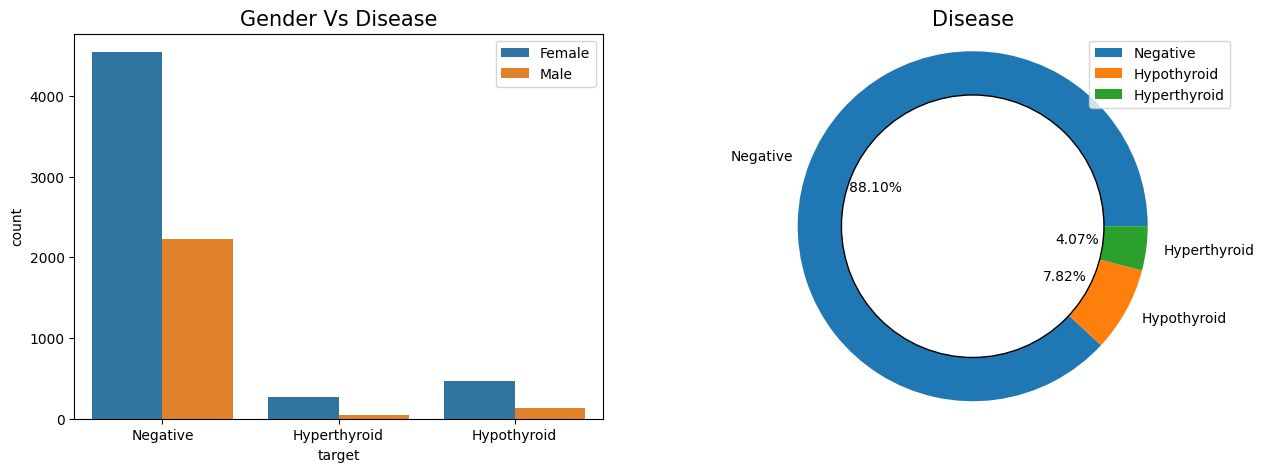

In [51]:
labels = ['Female','Male']
plt.figure(figsize=(15,5))

# Gender Vs Insights:
plt.subplot(1, 2, 1)
sns.countplot(data=data, x='target', hue='sex', alpha=1)
plt.legend(labels)
plt.title('Gender Vs Disease',size=15)

plt.subplot(1, 2, 2)  
Negative,Hypothyroid,Hyperthyroid = data['target'].value_counts()
y = [Negative,Hypothyroid,Hyperthyroid]
explode = [0, 0.0,0]
labels = ['Negative', 'Hypothyroid','Hyperthyroid']
# Disease
plt.pie(y, labels=labels, explode=explode,autopct='%.2f%%')
plt.axis('equal')
plt.legend(labels)
circle = plt.Circle(xy=(0, 0), radius=0.75, facecolor='White', edgecolor='black')
plt.gca().add_artist(circle)
plt.title('Disease', size=15)
plt.show()


The prevalence of hyperthyroidism and hypothyroidism is higher in females compared to males, indicating that females are more likely to develop thyroid conditions.



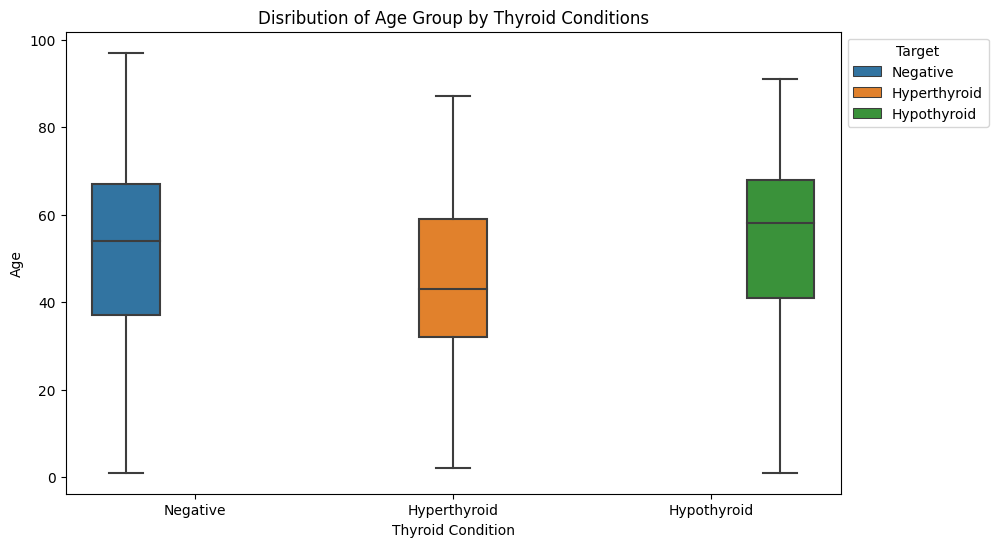

In [52]:
plt.figure(figsize = (10,6))
sns.boxplot(data, x='target', y='age', hue = 'target', )
plt.title('Disribution of Age Group by Thyroid Conditions')
plt.xlabel('Thyroid Condition')
plt.ylabel('Age')
plt.legend(loc='best', frameon=True, title = 'Target', bbox_to_anchor=(1, 1))
plt.show()

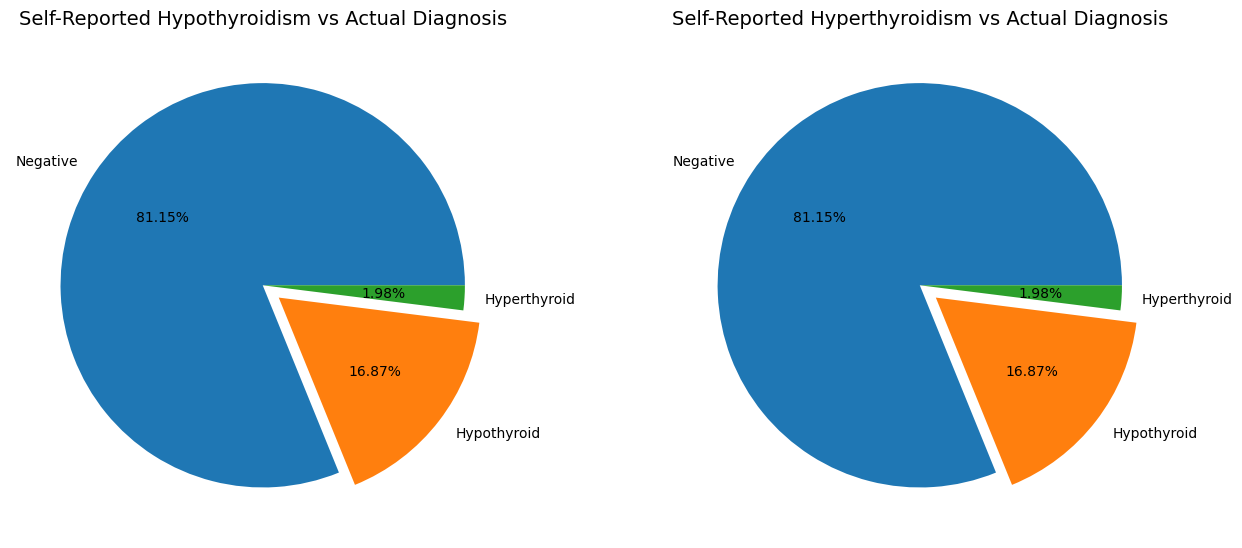

In [53]:
# Filter dataframes for self-reported conditions for Hypothyroid and Hyperthyroid,
# along with counts of target variable
df_query_hypo = df1[(df1['query_hypothyroid']=='t')]
df_query_hypo_counts = df_query_hypo['target'].value_counts()

df_query_hyper = df1[(df1['query_hypothyroid']=='t')]
df_query_hyper_counts = df_query_hyper['target'].value_counts()

# Generate Pie charts in subplots for self-reported hypothyroidism  and Hyperthyroidism
plt.figure(figsize = (15,10))

plt.subplot(1,2,1)
plt.pie(df_query_hypo_counts, labels=df_query_hypo_counts.index, explode=[0,0.1,0], autopct='%1.2f%%')
plt.title('Self-Reported Hypothyroidism vs Actual Diagnosis', fontdict={'fontsize':14})
plt.subplot(1,2,2)
plt.pie(df_query_hyper_counts, labels=df_query_hyper_counts.index, explode=[0,0.1,0], autopct='%1.2f%%')
plt.title('Self-Reported Hyperthyroidism vs Actual Diagnosis', fontdict={'fontsize':14})

# Display plots after adjusting the space between subplots
plt.subplots_adjust(wspace=0.3)
plt.show()


In [54]:
# Creating dataframe 'thyroxine_df' by grouping the 'on_thyroxine' and 'target' columns
# and counting the frequency of target classes
thyroxine_df = df1.groupby(['on_thyroxine', 'target'])['target'].count().reset_index(name = 'count')

# Map 'f' and 't' values in 'on_thyroxine' column of 'thyroxine_df' dataframe to 'False' and 'True' respectively
thyroxine_map = {'f':'False', 't':'True'}
thyroxine_df['on_thyroxine']= thyroxine_df['on_thyroxine'].map(thyroxine_map)
thyroxine_df

,on_thyroxine,target,count
0,False,Hyperthyroid,299
1,False,Hypothyroid,576
2,False,Negative,5949
3,True,Hyperthyroid,14
4,True,Hypothyroid,25
5,True,Negative,818


In [55]:
i131_counts = df1.groupby('target')['I131_treatment'].value_counts().unstack()
i131_counts

I131_treatment,f,t
target,,
Hyperthyroid,302,11
Hypothyroid,588,13
Negative,6645,122


In [56]:
surgery_counts = df1.groupby('target')['thyroid_surgery'].value_counts().unstack()
surgery_counts

thyroid_surgery,f,t
target,,
Hyperthyroid,298,15
Hypothyroid,597,4
Negative,6665,102


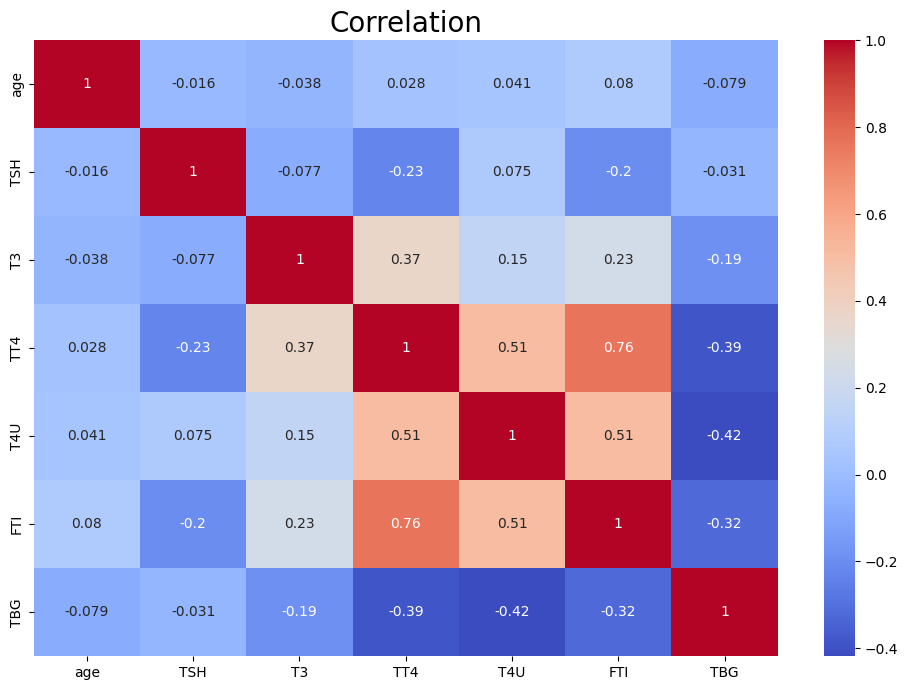

In [57]:
plt.figure(figsize=(12,8))
sns.heatmap(data.select_dtypes(include=['number']).corr(),annot=True,cmap='coolwarm')
plt.title("Correlation",fontsize=20)
plt.show()

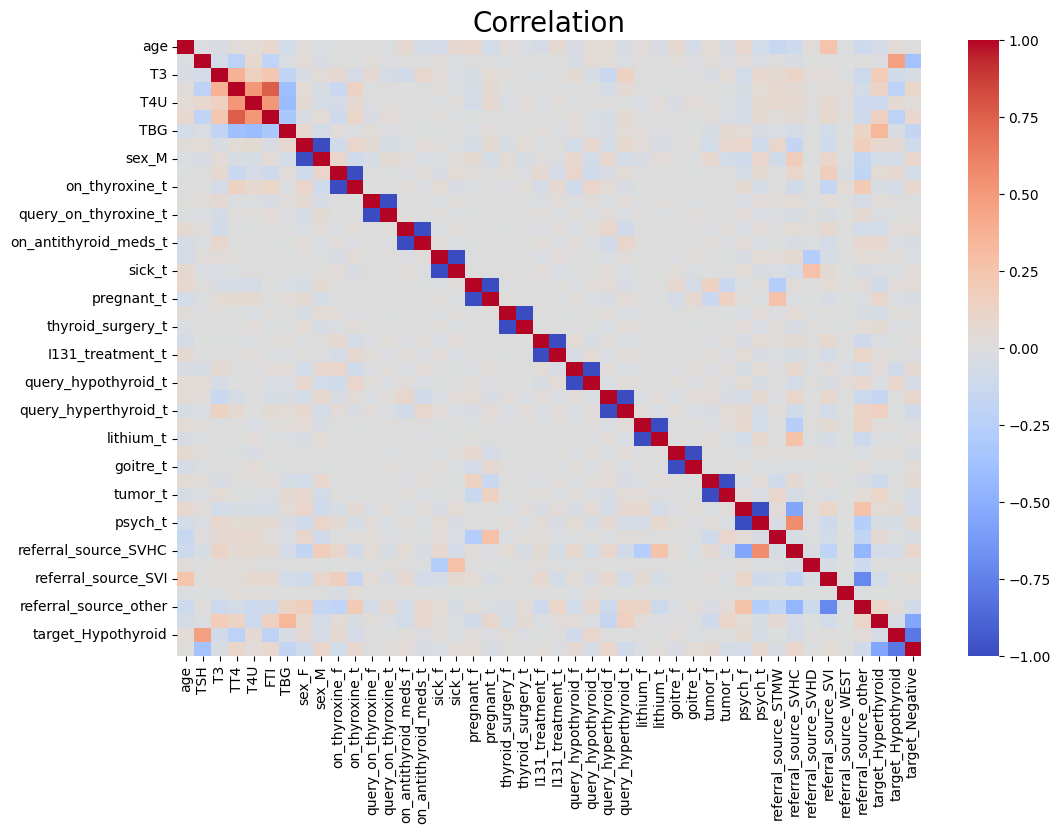

In [58]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data_encoded = pd.get_dummies(data)

# Create a correlation matrix
correlation_matrix = data_encoded.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title("Correlation", fontsize=20)
plt.show()

In [59]:
obj_col = []
for i in data.columns:
    if data[i].dtype == 'object':
        print(f'Unique values in {i}: {data[i].unique()}')
        obj_col.append(i)




Unique values in sex: ['F' 'M']
Unique values in on_thyroxine: ['f' 't']
Unique values in query_on_thyroxine: ['f' 't']
Unique values in on_antithyroid_meds: ['f' 't']
Unique values in sick: ['f' 't']
Unique values in pregnant: ['f' 't']
Unique values in thyroid_surgery: ['f' 't']
Unique values in I131_treatment: ['f' 't']
Unique values in query_hypothyroid: ['t' 'f']
Unique values in query_hyperthyroid: ['f' 't']
Unique values in lithium: ['f' 't']
Unique values in goitre: ['f' 't']
Unique values in tumor: ['f' 't']
Unique values in psych: ['f' 't']
Unique values in referral_source: ['other' 'SVI' 'SVHC' 'STMW' 'SVHD' 'WEST']
Unique values in target: ['Negative' 'Hyperthyroid' 'Hypothyroid']


In [60]:
le = LabelEncoder()


In [61]:
sex_map = {'F':0, 'M':1}
obj_col_map = {'f':0, 't':1}

In [62]:
sex_map = {'F':0, 'M':1}
obj_col_map = {'f':0, 't':1}

In [63]:
data['sex'] = data['sex'].map(sex_map)
data['referral_source'] = le.fit_transform(data['referral_source'])


In [64]:
for i in data.columns:
    if data[i].dtype == 'object' and i != 'target':
        data[i] = data[i].map(obj_col_map)

In [65]:
for i in obj_col:
        print(f'Unique values in {i}: {data[i].unique()}')

Unique values in sex: [0 1]
Unique values in on_thyroxine: [0 1]
Unique values in query_on_thyroxine: [0 1]
Unique values in on_antithyroid_meds: [0 1]
Unique values in sick: [0 1]
Unique values in pregnant: [0 1]
Unique values in thyroid_surgery: [0 1]
Unique values in I131_treatment: [0 1]
Unique values in query_hypothyroid: [1 0]
Unique values in query_hyperthyroid: [0 1]
Unique values in lithium: [0 1]
Unique values in goitre: [0 1]
Unique values in tumor: [0 1]
Unique values in psych: [0 1]
Unique values in referral_source: [5 3 1 0 2 4]
Unique values in target: ['Negative' 'Hyperthyroid' 'Hypothyroid']


In [66]:
# Splits the DataFrame into features (x) and target variable (y)
# List of columns that will be dropped
col_drop = ['tumor', 'psych', 'lithium',
               'goitre', 'sex', 'query_hypothyroid', 'query_hyperthyroid','pregnant','sick','query_on_thyroxine','referral_source']

data.drop(col_drop, axis = 1, inplace = True)
#tumor, psych, lithium, goitre, sex, query_hypothyroid, query_hyperthyroid, pregnant, sick, query_on_thyroxine, referral_source
x = data.drop('target', axis = 1)
y = data['target']

In [67]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)


In [68]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(6144, 11)
(1537, 11)
(6144,)
(1537,)


In [69]:
print(y_train.unique())


['Negative' 'Hypothyroid' 'Hyperthyroid']


In [70]:
# Creating a function 'au_prc' to plot AU-PRC curve along with Average Precision for each class
def au_prc(y_test_data, y_score_data):
    from sklearn.metrics import precision_recall_curve, average_precision_score
    from sklearn.preprocessing import label_binarize
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Binarize the labels for multi-class OvR
    classes = np.unique(y_test_data)
    y_true_binarized = label_binarize(y_test_data, classes=classes)
    
    # Store precision-recall metrics for each class
    precision_dict = {}
    recall_dict = {}
    average_precision_dict = {}
    for i, class_label in enumerate(classes):
        precision_dict[class_label], recall_dict[class_label], _ = precision_recall_curve(
            y_true_binarized[:, i], y_score_data[:, i]
        )
        average_precision_dict[class_label] = average_precision_score(
            y_true_binarized[:, i], y_score_data[:, i]
        )
    
    # Compute micro-average PR curve
    precision_micro, recall_micro, _ = precision_recall_curve(
        y_true_binarized.ravel(), y_score_data.ravel()
    )
    average_precision_micro = average_precision_score(y_true_binarized, y_score_data, average="micro")
    # Plot Precision-Recall Curve
    plt.figure(figsize=(8, 6))
    for class_label in classes:
        plt.plot(
            recall_dict[class_label], 
            precision_dict[class_label], 
            label=f"Class {class_label} (AP = {average_precision_dict[class_label]:.2f})"
        )
    
    # Add micro-average curve
    plt.plot(
        recall_micro, 
        precision_micro, 
        label=f"Micro-Average (AP = {average_precision_micro:.2f})", 
        color='gold', linestyle='--'
    )
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve for Multi-Class Classification")
    plt.legend(loc="best")
    plt.grid()
    plt.show()
        

In [71]:
from sklearn.ensemble import AdaBoostClassifier

adaboost_clf = AdaBoostClassifier(random_state=1)
adaboost_clf.fit(x_train, y_train)



AdaBoostClassifier(random_state=1)

              precision    recall  f1-score   support

Hyperthyroid       0.75      0.43      0.55        63
 Hypothyroid       0.97      0.96      0.97       120
    Negative       0.97      0.99      0.98      1354

    accuracy                           0.97      1537
   macro avg       0.90      0.79      0.83      1537
weighted avg       0.96      0.97      0.96      1537



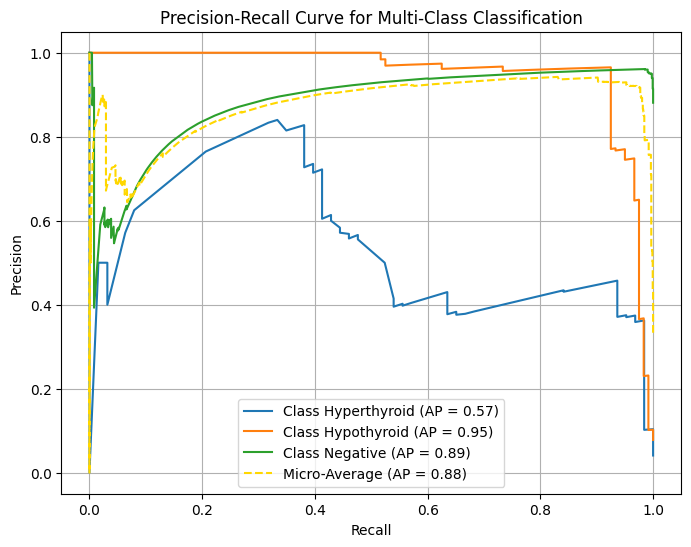

In [72]:

y_pred_adaboost = adaboost_clf.predict(x_test)
y_score = adaboost_clf.predict_proba(x_test)
y_test_binarized = label_binarize(y_test, classes=adaboost_clf.classes_)
# Generate the classification report
report = classification_report(y_test, y_pred_adaboost)
print(report)
au_prc(y_test_data= y_test, y_score_data= y_score)

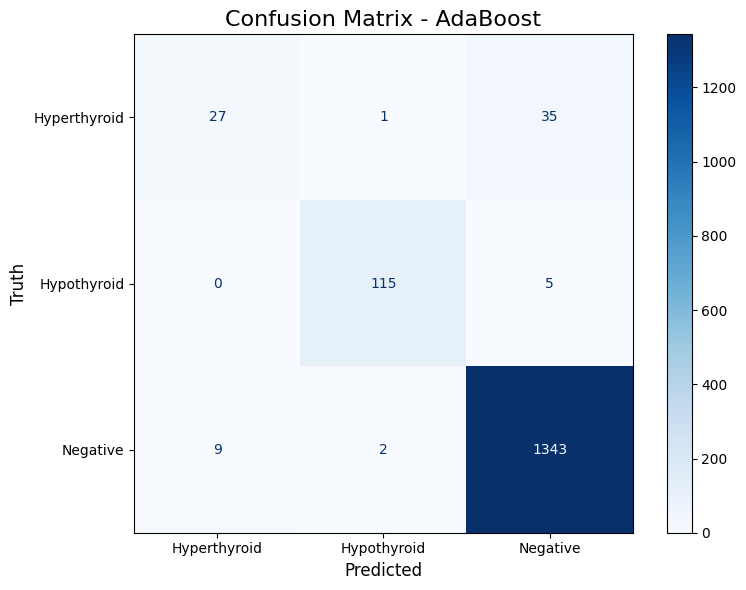

In [73]:
confusion = confusion_matrix(y_test, y_pred_adaboost)

# Display the confusion matrix with customization
disp = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=["Hyperthyroid", "Hypothyroid", "Negative"])
fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size
disp.plot(cmap="Blues", ax=ax, values_format="d")  # Customize colormap and value formatting

# Customize Title and Labels
ax.set_title("Confusion Matrix - AdaBoost", fontsize=16)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Truth", fontsize=12)

# Adjust Tick Label Sizes
ax.tick_params(axis="both", labelsize=10)

# Show the plot
plt.tight_layout()
plt.show()


Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best parameters: {'learning_rate': 0.5, 'n_estimators': 200}
Best accuracy score: 0.96
              precision    recall  f1-score   support

Hyperthyroid       0.67      0.46      0.55        63
 Hypothyroid       0.95      0.88      0.91       120
    Negative       0.97      0.99      0.98      1354

    accuracy                           0.96      1537
   macro avg       0.86      0.77      0.81      1537
weighted avg       0.95      0.96      0.95      1537



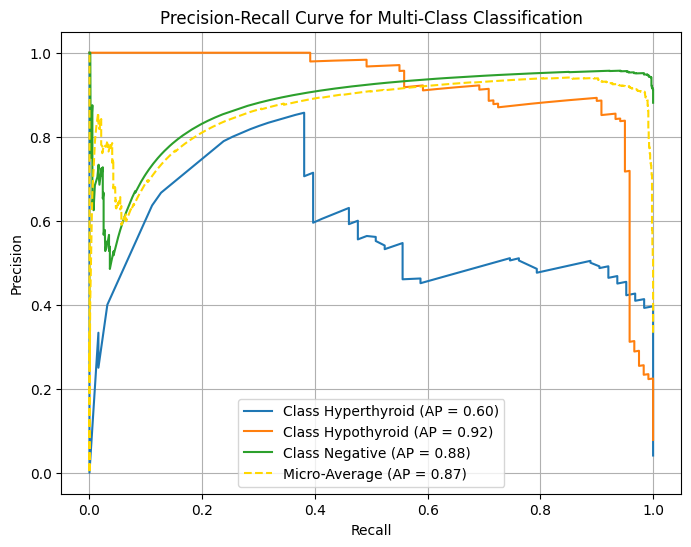

In [74]:
#Hyperparameter Tuning to optimize its performance.
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier



# Define the hyperparameter grid to search
param_grid = {
    'n_estimators': [100, 150, 200],  # Number of estimators
    'learning_rate': [0.1, 0.5, 1]  # Learning rate for boosting
}

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=adaboost_clf, param_grid=param_grid,
                           cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# Fit the grid search to the training data
grid_search.fit(x_train, y_train)

# Print the best parameters and the best score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best accuracy score: {grid_search.best_score_:.2f}")

best_adaboost = grid_search.best_estimator_

# Make predictions using the tuned model
y_pred_best = best_adaboost.predict(x_test)
# Use the best model for predictions
report = classification_report(y_test, y_pred_best)
print(report)
y_score = best_adaboost.predict_proba(x_test)


au_prc(y_test_data= y_test, y_score_data= y_score)




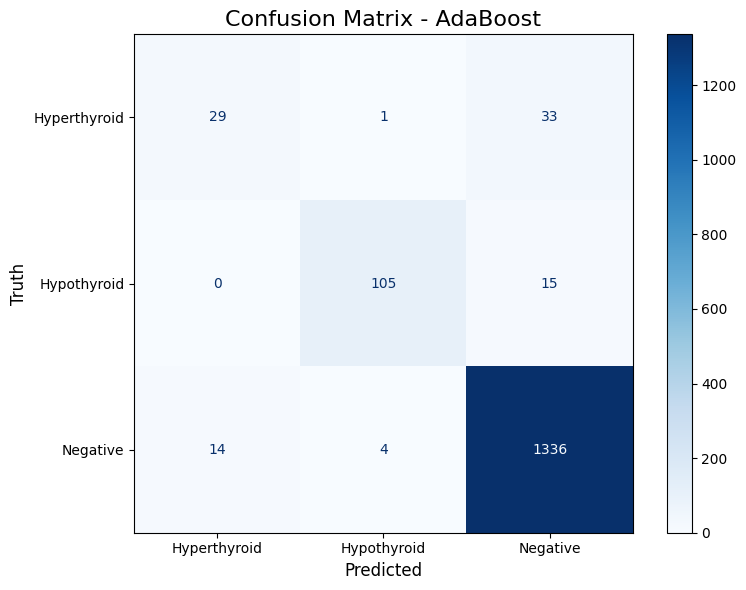

In [75]:
confusion = confusion_matrix(y_test, y_pred_best)

# Display the confusion matrix with customization
disp = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=["Hyperthyroid", "Hypothyroid", "Negative"])
fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size
disp.plot(cmap="Blues", ax=ax, values_format="d")  # Customize colormap and value formatting

# Customize Title and Labels
ax.set_title("Confusion Matrix - AdaBoost", fontsize=16)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Truth", fontsize=12)

# Adjust Tick Label Sizes
ax.tick_params(axis="both", labelsize=10)

# Show the plot
plt.tight_layout()
plt.show()

Accuracy with Balanced Class Weights: 0.9726740403383214
              precision    recall  f1-score   support

Hyperthyroid       0.75      0.70      0.72        63
 Hypothyroid       0.96      0.96      0.96       120
    Negative       0.98      0.99      0.99      1354

    accuracy                           0.97      1537
   macro avg       0.90      0.88      0.89      1537
weighted avg       0.97      0.97      0.97      1537



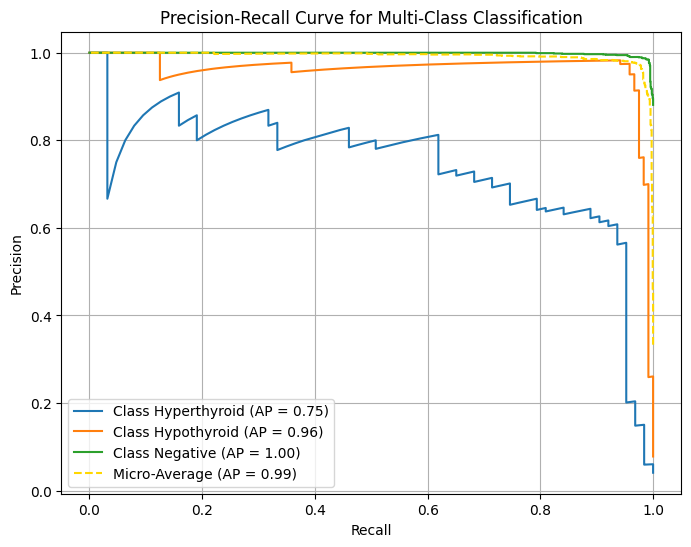

In [76]:
# Training the AdaBoostClassifier Classifier with Balanced Class Weights
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Create the base estimator with balanced class weights
base_classifier = DecisionTreeClassifier(max_depth=2, class_weight='balanced')

# Create the AdaBoostClassifier with the balanced base classifier
adaboost_balanced = AdaBoostClassifier(base_estimator=base_classifier, n_estimators=150, random_state=42)

# Train the AdaBoostClassifier
adaboost_balanced.fit(x_train, y_train)

# Evaluate
accuracy = adaboost_balanced.score(x_test, y_test)
print(f"Accuracy with Balanced Class Weights: {accuracy}")
y_pred = adaboost_balanced.predict(x_test)

# Generate the classification report
report = classification_report(y_test, y_pred)
print(report)
y_score = adaboost_balanced.predict_proba(x_test)

y_test_binarized = label_binarize(y_test, classes=adaboost_balanced.classes_)

au_prc(y_test_data= y_test, y_score_data= y_score)

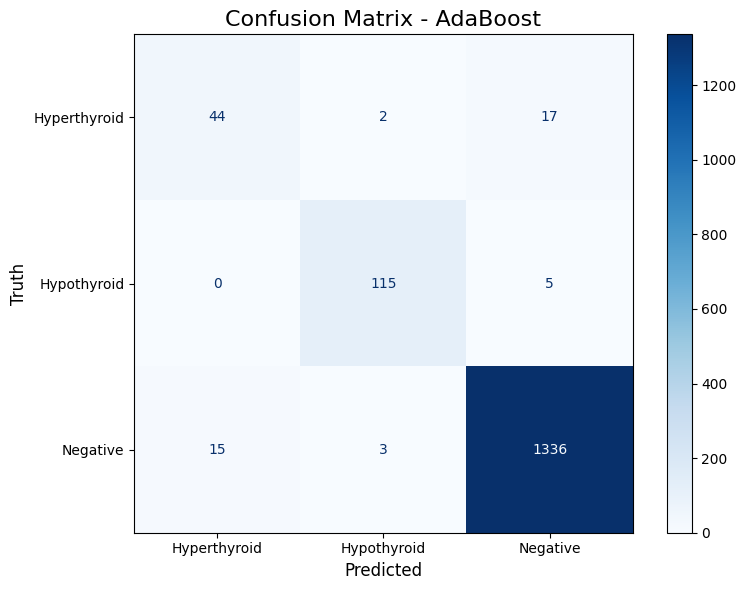

In [77]:
confusion = confusion_matrix(y_test, y_pred)

# Display the confusion matrix with customization
disp = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=["Hyperthyroid", "Hypothyroid", "Negative"])
fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size
disp.plot(cmap="Blues", ax=ax, values_format="d")  # Customize colormap and value formatting

# Customize Title and Labels
ax.set_title("Confusion Matrix - AdaBoost", fontsize=16)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Truth", fontsize=12)

# Adjust Tick Label Sizes
ax.tick_params(axis="both", labelsize=10)

# Show the plot
plt.tight_layout()
plt.show()


Accuracy with Weighted Classes: 0.9661678594664932
AdaBoostClassifier:
              precision    recall  f1-score   support

Hyperthyroid       0.76      0.81      0.78        63
 Hypothyroid       0.97      0.96      0.96       120
    Negative       0.99      0.99      0.99      1354

    accuracy                           0.98      1537
   macro avg       0.91      0.92      0.91      1537
weighted avg       0.98      0.98      0.98      1537



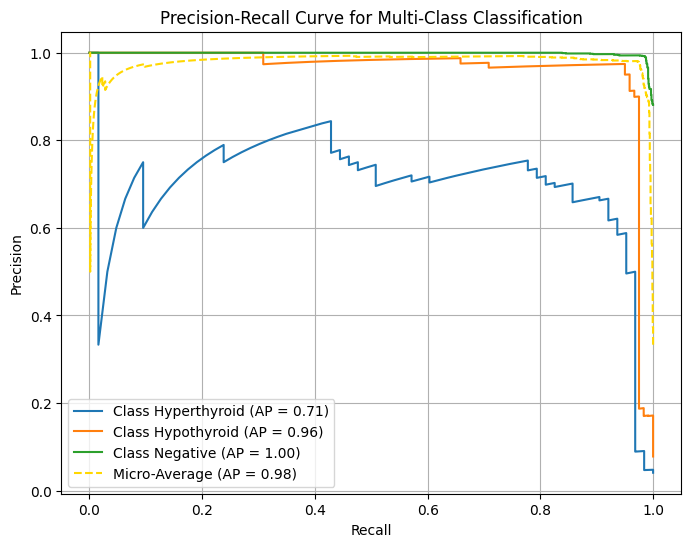

In [78]:
# Training the AdaBoostClassifier Classifier with Customized Class Weights
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Adjusted class weights based on the dataset
class_weights = {'Negative': 0.38, 'Hypothyroid': 4.26, 'Hyperthyroid': 8.17}

# Base classifier with class weights
base_classifier = DecisionTreeClassifier(max_depth=2, class_weight=class_weights)

# AdaBoost classifier with the weighted base classifier
adaboost_clf_based = AdaBoostClassifier(base_estimator=base_classifier, n_estimators=150, random_state=42)

# Train the model
adaboost_clf_based.fit(x_train, y_train)

# Evaluate the model
accuracy = adaboost_clf.score(x_test, y_test)
print(f"Accuracy with Weighted Classes: {accuracy}")
y_scorew = adaboost_clf_based.predict_proba(x_test)
y_pred = adaboost_clf_based.predict(x_test)
y_test_binarized = label_binarize(y_test, classes=adaboost_clf.classes_)
print("AdaBoostClassifier:")

# Generate the classification report
report = classification_report(y_test, y_pred)
print(report)

# Generate the classification report

au_prc(y_test_data= y_test, y_score_data= y_scorew)



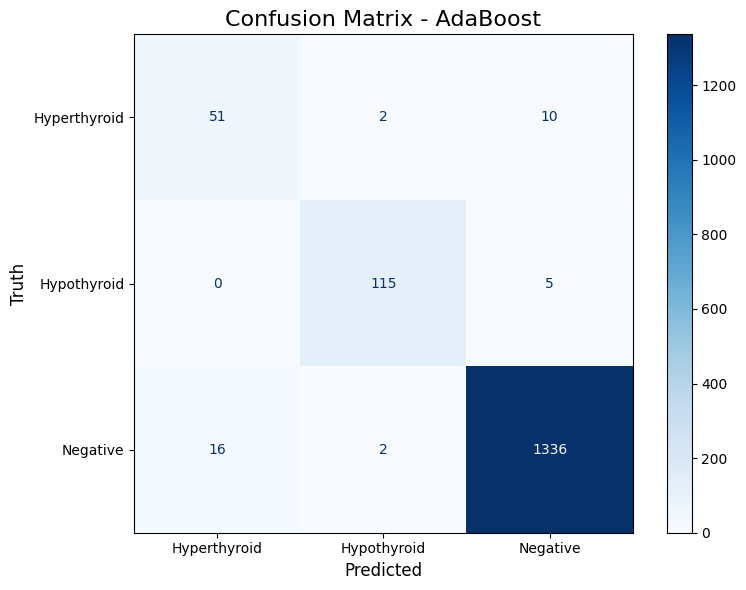

In [79]:
confusion = confusion_matrix(y_test, y_pred)

# Display the confusion matrix with customization
disp = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=["Hyperthyroid", "Hypothyroid", "Negative"])
fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size
disp.plot(cmap="Blues", ax=ax, values_format="d")  # Customize colormap and value formatting

# Customize Title and Labels
ax.set_title("Confusion Matrix - AdaBoost", fontsize=16)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Truth", fontsize=12)

# Adjust Tick Label Sizes
ax.tick_params(axis="both", labelsize=10)

# Show the plot
plt.tight_layout()
plt.show()


LogisticRegression:
              precision    recall  f1-score   support

Hyperthyroid       0.83      0.40      0.54        63
 Hypothyroid       0.91      0.58      0.71       120
    Negative       0.94      0.99      0.97      1354

    accuracy                           0.94      1537
   macro avg       0.89      0.66      0.74      1537
weighted avg       0.93      0.94      0.93      1537



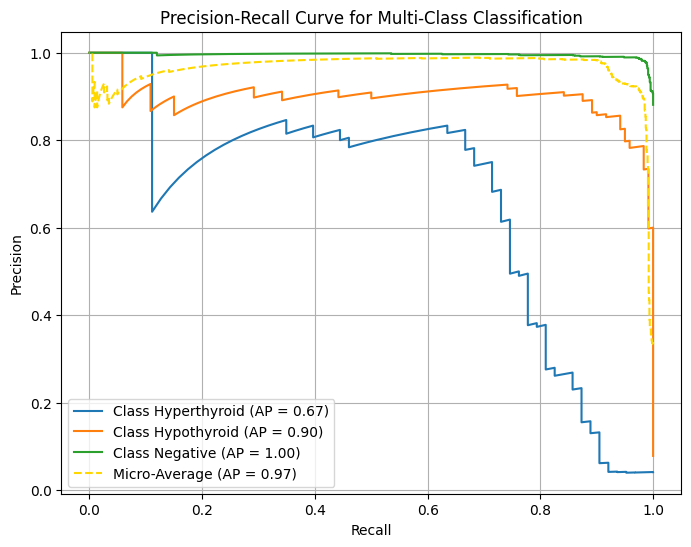

In [80]:

from sklearn.linear_model import LogisticRegression

#List of columns with continuous values and the copies of x_train and x_test
col_to_encode = ['TSH', 'T3', 'TT4', 'T4U', 'FTI', 'TBG']
x_train_lr = x_train.copy()
x_test_lr = x_test.copy()

#Creating object for the class Standard Scaler
sc = StandardScaler()

# Transform the values of columns in 'col_to_encode' for both training and test features
x_train_lr[col_to_encode] = sc.fit_transform(x_train_lr[col_to_encode])
x_test_lr[col_to_encode] = sc.transform(x_test_lr[col_to_encode])
# Training Logistic Regression
lr = LogisticRegression()
lr.fit(x_train_lr, y_train)

# Making Predictions
y_pred = lr.predict(x_test_lr)
y_score = lr.predict_proba(x_test_lr)

# Binarize the target for multiclass precision
y_test_binarized = label_binarize(y_test, classes=lr.classes_)

#Evaluate
print("LogisticRegression:")

report = classification_report(y_test, y_pred)
print(report)


# Micro Average Precision (unweighted mean)
au_prc(y_test_data= y_test, y_score_data= y_score)

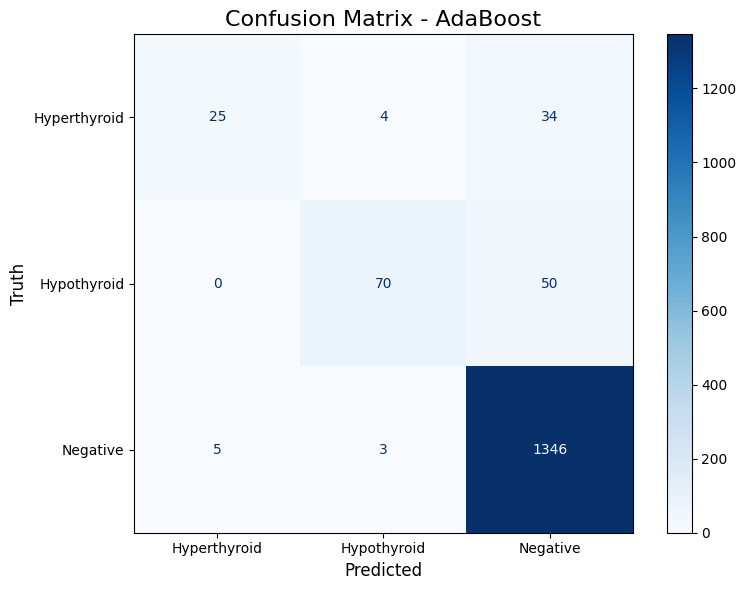

In [81]:

confusion = confusion_matrix(y_test, y_pred)

# Display the confusion matrix with customization
disp = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=["Hyperthyroid", "Hypothyroid", "Negative"])
fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size
disp.plot(cmap="Blues", ax=ax, values_format="d")  # Customize colormap and value formatting

# Customize Title and Labels
ax.set_title("Confusion Matrix - AdaBoost", fontsize=16)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Truth", fontsize=12)

# Adjust Tick Label Sizes
ax.tick_params(axis="both", labelsize=10)

# Show the plot
plt.tight_layout()
plt.show()

Decision Tree Classifier:
Accuracy: 0.98
              precision    recall  f1-score   support

Hyperthyroid       0.83      0.79      0.81        63
 Hypothyroid       0.97      0.93      0.95       120
    Negative       0.99      0.99      0.99      1354

    accuracy                           0.98      1537
   macro avg       0.93      0.90      0.92      1537
weighted avg       0.98      0.98      0.98      1537



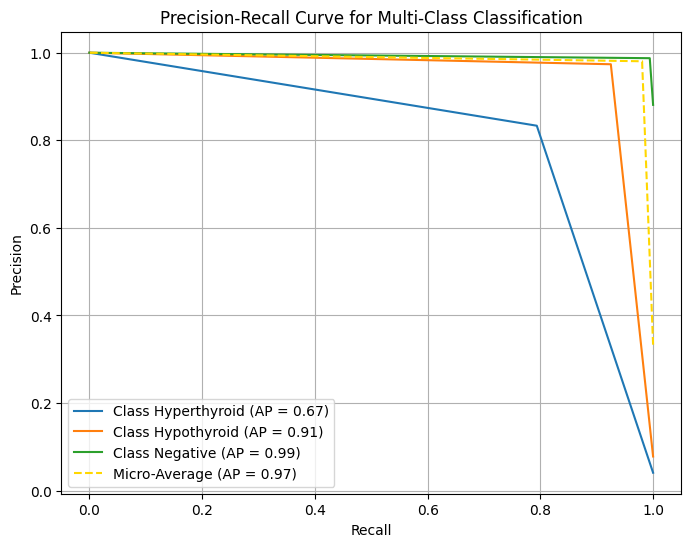

In [82]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay

# Train DecisionTreeClassifier
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(x_train, y_train)

# Evaluate on test data
y_pred_tree = decision_tree.predict(x_test)
accuracy_tree = accuracy_score(y_test, y_pred_tree)
y_score= decision_tree.predict_proba(x_test)

# Print classification report
print("Decision Tree Classifier:")
print(f"Accuracy: {accuracy_tree:.2f}")
print(classification_report(y_test, y_pred_tree))

# Plot confusion matrix

au_prc(y_test_data= y_test, y_score_data= y_score)

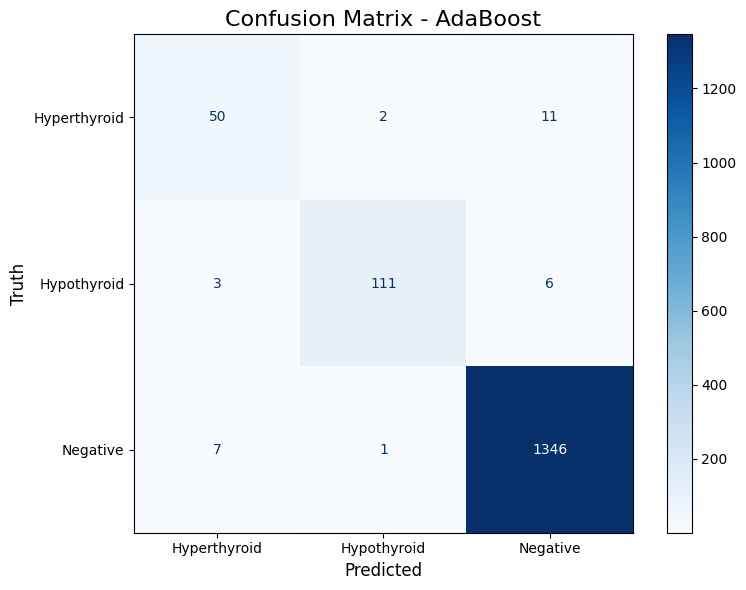

In [83]:
confusion = confusion_matrix(y_test, y_pred_tree)

# Display the confusion matrix with customization
disp = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=["Hyperthyroid", "Hypothyroid", "Negative"])
fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size
disp.plot(cmap="Blues", ax=ax, values_format="d")  # Customize colormap and value formatting

# Customize Title and Labels
ax.set_title("Confusion Matrix - AdaBoost", fontsize=16)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Truth", fontsize=12)

# Adjust Tick Label Sizes
ax.tick_params(axis="both", labelsize=10)

# Show the plot
plt.tight_layout()
plt.show()

In [84]:

import pandas as pd

# Data for each model
data = {
    "Model": ["Decision Tree", "Logistic Regression", "AdaBoost"],
    "Accuracy": [0.98, 0.94, 0.98],
    "Precision (Macro Avg)": [0.93, 0.89, 0.91],
    "Recall (Macro Avg)": [0.90, 0.66, 0.92],
    "F1-Score (Macro Avg)": [0.92, 0.74, 0.91]
}

# Create DataFrame
comparison_df = pd.DataFrame(data)
print(comparison_df)


                 Model  Accuracy  Precision (Macro Avg)  Recall (Macro Avg)  \
0        Decision Tree      0.98                   0.93                0.90   
1  Logistic Regression      0.94                   0.89                0.66   
2             AdaBoost      0.98                   0.91                0.92   

   F1-Score (Macro Avg)  
0                  0.92  
1                  0.74  
2                  0.91  


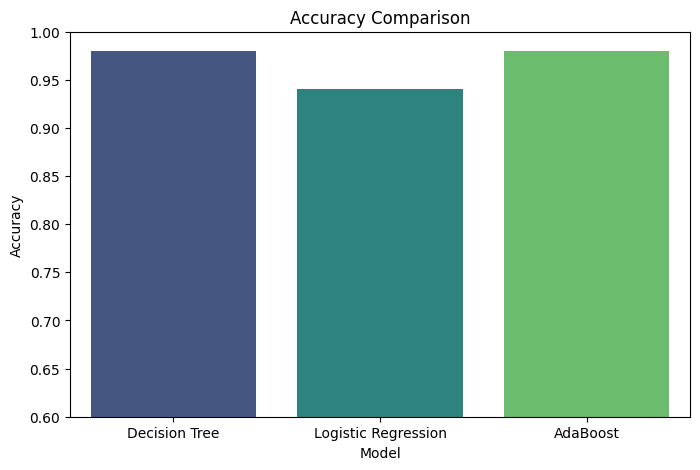

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar plot for Accuracy
plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="Accuracy", data=comparison_df, palette="viridis")
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.6, 1.0)
plt.show()


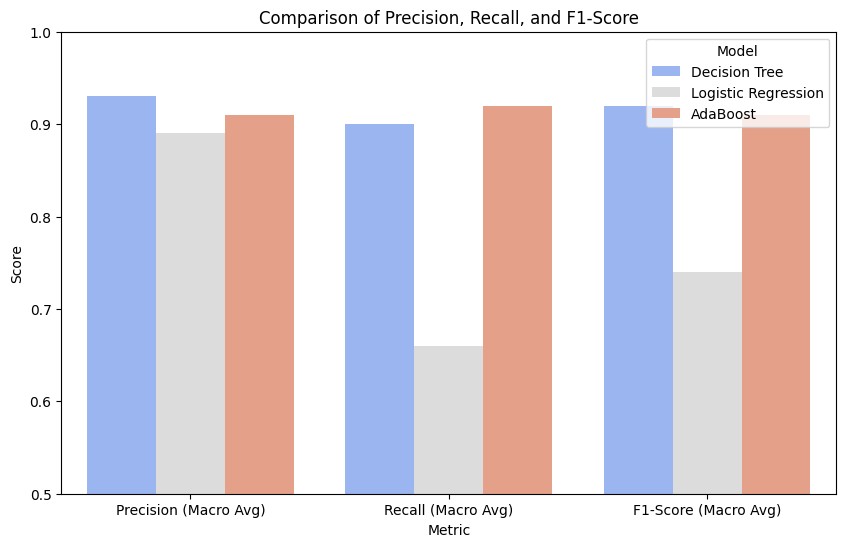

In [86]:
# Create DataFrame for macro metrics
metrics_df = comparison_df.melt(id_vars="Model", 
                                 value_vars=["Precision (Macro Avg)", "Recall (Macro Avg)", "F1-Score (Macro Avg)"],
                                 var_name="Metric", value_name="Value")

# Bar plot for Macro Metrics
plt.figure(figsize=(10, 6))
sns.barplot(x="Metric", y="Value", hue="Model", data=metrics_df, palette="coolwarm")
plt.title("Comparison of Precision, Recall, and F1-Score")
plt.ylabel("Score")
plt.ylim(0.5, 1.0)
plt.legend(title="Model")
plt.show()



In [87]:
import pandas as pd

# بيانات من التقرير الخاص بكل فئة (Hyperthyroid, Hypothyroid, Negative)
class_metric_data = {
    "Model": ["Decision Tree"] * 3 + ["Logistic Regression"] * 3 + ["AdaBoost"] * 3,
    "Class": ["Hyperthyroid", "Hypothyroid", "Negative"] * 3,
    "Precision": [0.83, 0.97, 0.99,  # Decision Tree
                  0.83, 0.91, 0.94,  # Logistic Regression
                  0.76, 0.97, 0.99],  # AdaBoost
    "Recall": [0.79, 0.93, 0.99,  # Decision Tree
               0.40, 0.58, 0.99,  # Logistic Regression
               0.81, 0.96, 0.99],  # AdaBoost
    "F1-Score": [0.81, 0.95, 0.99,  # Decision Tree
                 0.54, 0.71, 0.97,  # Logistic Regression
                 0.78, 0.96, 0.99]  # AdaBoost
}

# إنشاء DataFrame
class_df = pd.DataFrame(class_metric_data)
print(class_df)


                 Model         Class  Precision  Recall  F1-Score
0        Decision Tree  Hyperthyroid       0.83    0.79      0.81
1        Decision Tree   Hypothyroid       0.97    0.93      0.95
2        Decision Tree      Negative       0.99    0.99      0.99
3  Logistic Regression  Hyperthyroid       0.83    0.40      0.54
4  Logistic Regression   Hypothyroid       0.91    0.58      0.71
5  Logistic Regression      Negative       0.94    0.99      0.97
6             AdaBoost  Hyperthyroid       0.76    0.81      0.78
7             AdaBoost   Hypothyroid       0.97    0.96      0.96
8             AdaBoost      Negative       0.99    0.99      0.99


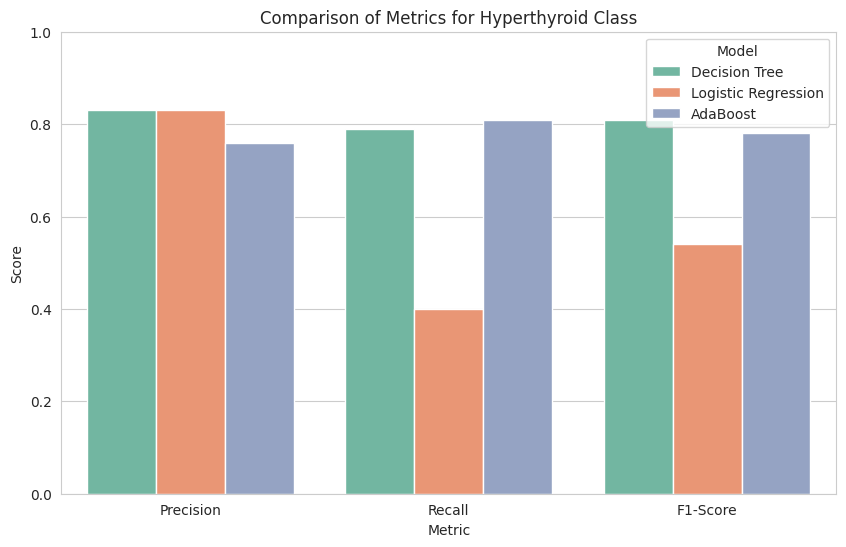

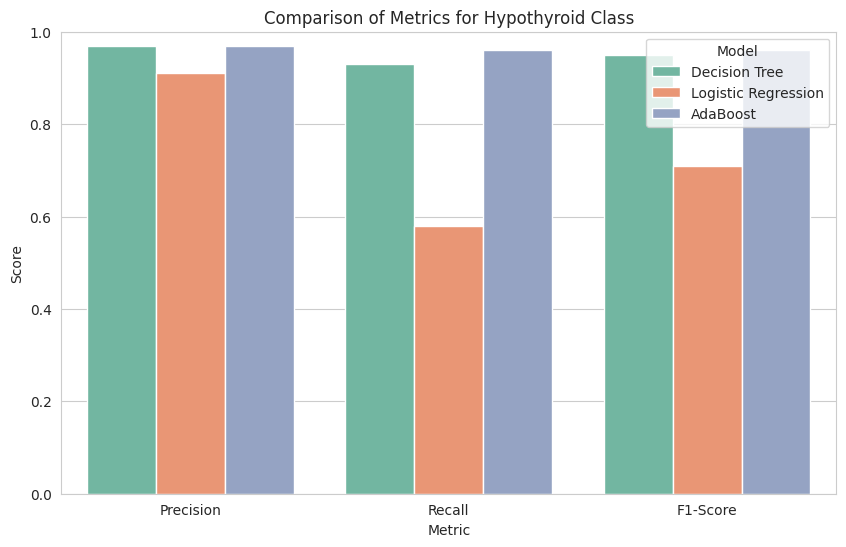

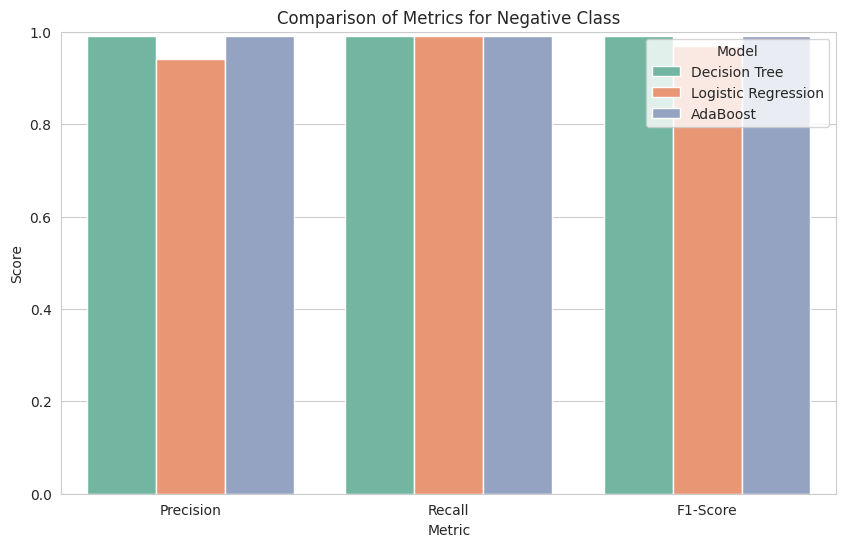

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

# ضبط النمط
sns.set_style("whitegrid")

# رسم الرسومات لكل فئة
for cls in ["Hyperthyroid", "Hypothyroid", "Negative"]:
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x="Metric",
        y="Value",
        hue="Model",
        data=pd.melt(
            class_df[class_df["Class"] == cls],
            id_vars=["Model", "Class"],
            value_vars=["Precision", "Recall", "F1-Score"],
            var_name="Metric",
            value_name="Value"
        ),
        palette="Set2"
    )
    plt.title(f"Comparison of Metrics for {cls} Class")
    plt.ylabel("Score")
    plt.ylim(0, 1)  # القيم بين 0 و 1
    plt.show()



In [89]:
import pandas as pd

# Data for comparison
metric_data = {
    "Model": ["Decision Tree", "Decision Tree", "Decision Tree",
              "Logistic Regression", "Logistic Regression", "Logistic Regression",
              "AdaBoost", "AdaBoost", "AdaBoost"],
    "Metric": ["Precision", "Recall", "F1-Score"] * 3,
    "Value": [0.93, 0.90, 0.92,  # Decision Tree
              0.89, 0.66, 0.74,  # Logistic Regression
              0.91, 0.92, 0.91]  # AdaBoost
}

# Create a DataFrame
metrics_df = pd.DataFrame(metric_data)
print(metrics_df)


                 Model     Metric  Value
0        Decision Tree  Precision   0.93
1        Decision Tree     Recall   0.90
2        Decision Tree   F1-Score   0.92
3  Logistic Regression  Precision   0.89
4  Logistic Regression     Recall   0.66
5  Logistic Regression   F1-Score   0.74
6             AdaBoost  Precision   0.91
7             AdaBoost     Recall   0.92
8             AdaBoost   F1-Score   0.91


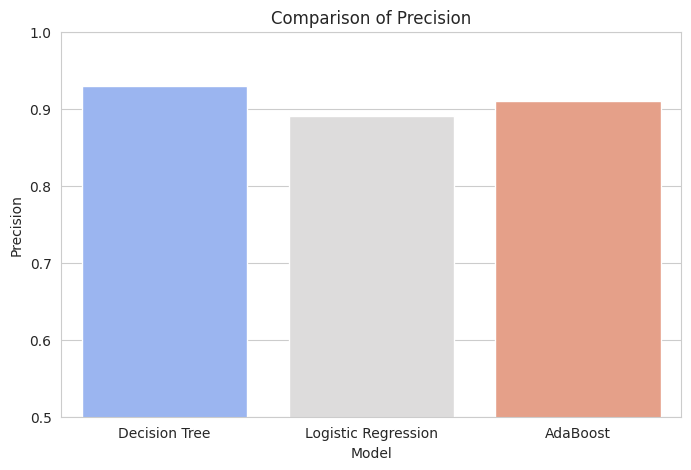

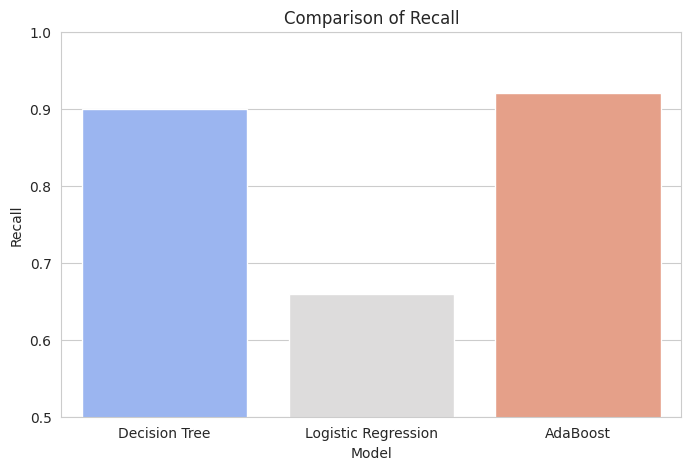

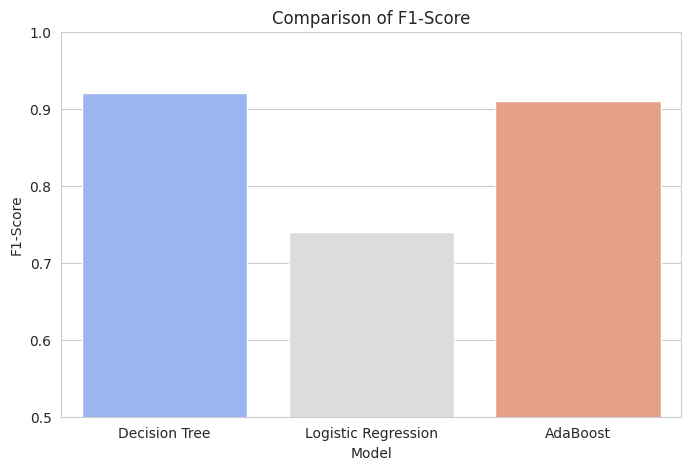

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for Seaborn
sns.set_style("whitegrid")

# Plot for each metric
metrics = ["Precision", "Recall", "F1-Score"]
for metric in metrics:
    plt.figure(figsize=(8, 5))
    sns.barplot(
        x="Model", 
        y="Value", 
        data=metrics_df[metrics_df["Metric"] == metric], 
        palette="coolwarm"
    )
    plt.title(f"Comparison of {metric}")
    plt.ylim(0.5, 1.0)  # Adjust the y-axis to match your data range
    plt.ylabel(metric)
    plt.xlabel("Model")
    plt.show()
